In [1]:
%pip install torch


In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split

print("PyTorch version:", torch.__version__)

PyTorch version: 2.11.0+cpu


In [3]:
%pip install tiktoken pandas numpy scikit-learn matplotlib

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tiktoken

from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader

print("All libraries imported successfully!")

All libraries imported successfully!


In [5]:
df = pd.read_csv("/content/IMDB Dataset.csv")

print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (50000, 2)
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


In [6]:
df = df.sample(n=3000, random_state=42).reset_index(drop=True)

print("Sampled dataset shape:", df.shape)

Sampled dataset shape: (3000, 2)


In [7]:
df["label"] = df["sentiment"].map({
    "negative": 0,
    "positive": 1
})

print(df[["sentiment", "label"]].head(10))

  sentiment  label
0  positive      1
1  positive      1
2  negative      0
3  positive      1
4  negative      0
5  positive      1
6  positive      1
7  positive      1
8  negative      0
9  negative      0


In [8]:
X = df["review"].values
y = df["label"].values

print("Reviews:", len(X))
print("Labels:", len(y))

Reviews: 3000
Labels: 3000


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 2400
Testing samples: 600


In [10]:
encoding = tiktoken.get_encoding("cl100k_base")

print("Tokenizer loaded successfully!")
print("Vocabulary size:", encoding.n_vocab)


Tokenizer loaded successfully!
Vocabulary size: 100277


In [11]:
X_train_tokens = [
    encoding.encode(review)
    for review in X_train
]

X_test_tokens = [
    encoding.encode(review)
    for review in X_test
]

print("Original review:")
print(X_train[0][:300])

print("\nFirst 30 token IDs:")
print(X_train_tokens[0][:30])

Original review:
Well...I like this movie first of all because it's very well thought of... and well..because the um...director and others chose an extremely great actor to play Mike....and also my last reason because ( my opinion) Elijah Wood is so so hot!!!

First 30 token IDs:
[11649, 1131, 40, 1093, 420, 5818, 1176, 315, 682, 1606, 433, 596, 1633, 1664, 3463, 315, 1131, 323, 1664, 497, 28753, 279, 4543, 1131, 70895, 323, 3885, 14896, 459, 9193]


In [12]:
train_lengths = [len(seq) for seq in X_train_tokens]

print("Shortest review:", min(train_lengths))
print("Longest review:", max(train_lengths))
print("Average token length:", round(np.mean(train_lengths), 2))

Shortest review: 33
Longest review: 1460
Average token length: 297.3


In [13]:
MAX_LENGTH = 200
PAD_TOKEN = 0

def pad_sequences(sequences, max_length):
    padded = []

    for seq in sequences:

        if len(seq) > max_length:
            seq = seq[:max_length]

        else:
            seq = seq + [PAD_TOKEN] * (max_length - len(seq))

        padded.append(seq)

    return np.array(padded, dtype=np.int64)

print("Maximum sequence length:", MAX_LENGTH)

Maximum sequence length: 200


In [14]:
X_train_padded = pad_sequences(
    X_train_tokens,
    MAX_LENGTH
)

X_test_padded = pad_sequences(
    X_test_tokens,
    MAX_LENGTH
)

print("Training shape:", X_train_padded.shape)
print("Testing shape:", X_test_padded.shape)

Training shape: (2400, 200)
Testing shape: (600, 200)


In [15]:
X_train_tensor = torch.tensor(
    X_train_padded,
    dtype=torch.long
)

X_test_tensor = torch.tensor(
    X_test_padded,
    dtype=torch.long
)

y_train_tensor = torch.tensor(
    y_train,
    dtype=torch.float32
)

y_test_tensor = torch.tensor(
    y_test,
    dtype=torch.float32
)

print("X_train:", X_train_tensor.shape)
print("y_train:", y_train_tensor.shape)
print("X_test:", X_test_tensor.shape)
print("y_test:", y_test_tensor.shape)

X_train: torch.Size([2400, 200])
y_train: torch.Size([2400])
X_test: torch.Size([600, 200])
y_test: torch.Size([600])


In [16]:
train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

print("Training batches:", len(train_loader))
print("Testing batches:", len(test_loader))

Training batches: 75
Testing batches: 19


In [17]:
train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

print("Training batches:", len(train_loader))
print("Testing batches:", len(test_loader))

Training batches: 75
Testing batches: 19


In [18]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

Using device: cpu


In [19]:
class RNNClassifier(nn.Module):

    def __init__(self, vocab_size, embedding_dim, hidden_dim):
        super().__init__()

        # Embedding layer
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=PAD_TOKEN
        )

        # RNN layer
        self.rnn = nn.RNN(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            batch_first=True
        )

        # Linear output layer
        self.fc = nn.Linear(
            hidden_dim,
            1
        )

    def forward(self, x):

        # Convert token IDs into embeddings
        embedded = self.embedding(x)

        # Pass embeddings through RNN
        output, hidden = self.rnn(embedded)

        # Take the final hidden state
        last_hidden = hidden[-1]

        # Linear classification layer
        output = self.fc(last_hidden)

        return output.squeeze(1)

In [20]:
VOCAB_SIZE = encoding.n_vocab
EMBEDDING_DIM = 64
HIDDEN_DIM = 64

model = RNNClassifier(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM
)

model = model.to(device)

print(model)

RNNClassifier(
  (embedding): Embedding(100277, 64, padding_idx=0)
  (rnn): RNN(64, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


In [21]:
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss function:", criterion)
print("Optimizer: Adam")

Loss function: BCEWithLogitsLoss()
Optimizer: Adam


In [22]:
EPOCHS = 15

loss_history = []

for epoch in range(EPOCHS):

    model.train()

    total_loss = 0

    for batch_X, batch_y in train_loader:

        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        outputs = model(batch_X)

        loss = criterion(outputs, batch_y)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    average_loss = total_loss / len(train_loader)

    loss_history.append(average_loss)

    print(
        f"Epoch [{epoch + 1}/{EPOCHS}] "
        f"Loss: {average_loss:.4f}"
    )

Epoch [1/15] Loss: 0.6983
Epoch [2/15] Loss: 0.6740
Epoch [3/15] Loss: 0.6501
Epoch [4/15] Loss: 0.6116
Epoch [5/15] Loss: 0.6536
Epoch [6/15] Loss: 0.6657
Epoch [7/15] Loss: 0.6418
Epoch [8/15] Loss: 0.6104
Epoch [9/15] Loss: 0.5841
Epoch [10/15] Loss: 0.5491
Epoch [11/15] Loss: 0.5176
Epoch [12/15] Loss: 0.4755
Epoch [13/15] Loss: 0.4474
Epoch [14/15] Loss: 0.4130
Epoch [15/15] Loss: 0.3932


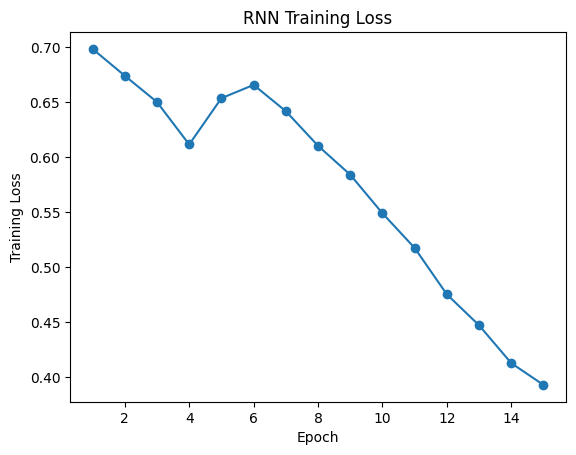

In [23]:
import matplotlib.pyplot as plt

plt.plot(
    range(1, EPOCHS + 1),
    loss_history,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("RNN Training Loss")

plt.show()

In [24]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for batch_X, batch_y in test_loader:

        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        outputs = model(batch_X)

        probabilities = torch.sigmoid(outputs)

        predictions = (probabilities >= 0.5).float()

        correct += (
            predictions == batch_y
        ).sum().item()

        total += batch_y.size(0)

accuracy = correct / total

print("Correct predictions:", correct)
print("Total test samples:", total)
print("Test Accuracy:", round(accuracy, 4))
print("Test Accuracy (%):", round(accuracy * 100, 2))

Correct predictions: 312
Total test samples: 600
Test Accuracy: 0.52
Test Accuracy (%): 52.0


In [25]:
def predict_sentiment(review):

    model.eval()

    # Tokenize
    tokens = encoding.encode(review)

    # Pad
    padded = pad_sequences(
        [tokens],
        MAX_LENGTH
    )

    # Convert to tensor
    tensor = torch.tensor(
        padded,
        dtype=torch.long
    ).to(device)

    # Prediction
    with torch.no_grad():

        output = model(tensor)

        probability = torch.sigmoid(output).item()

    if probability >= 0.5:
        sentiment = "POSITIVE"
    else:
        sentiment = "NEGATIVE"

    print("Review:")
    print(review)

    print("\nPositive probability:", round(probability, 4))
    print("Prediction:", sentiment)

In [26]:
predict_sentiment(
    "This movie was absolutely wonderful. "
    "The acting was excellent and I really enjoyed it."
)

Review:
This movie was absolutely wonderful. The acting was excellent and I really enjoyed it.

Positive probability: 0.5088
Prediction: POSITIVE


In [27]:
predict_sentiment(
    "This movie was extremely boring and disappointing. "
    "The story was terrible and the acting was very poor."
)

Review:
This movie was extremely boring and disappointing. The story was terrible and the acting was very poor.

Positive probability: 0.4323
Prediction: NEGATIVE


In [28]:
class LSTMClassifier(nn.Module):

    def __init__(self, vocab_size, embedding_dim, hidden_dim):
        super().__init__()

        # Embedding layer
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=PAD_TOKEN
        )

        # LSTM layer
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            batch_first=True
        )

        # Linear output layer
        self.fc = nn.Linear(
            hidden_dim,
            1
        )

    def forward(self, x):

        # Token IDs → embeddings
        embedded = self.embedding(x)

        # Pass embeddings through LSTM
        output, (hidden, cell) = self.lstm(embedded)

        # Take final hidden state
        last_hidden = hidden[-1]

        # Linear classification
        output = self.fc(last_hidden)

        return output.squeeze(1)

In [29]:
lstm_model = LSTMClassifier(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM
)

lstm_model = lstm_model.to(device)

print(lstm_model)

LSTMClassifier(
  (embedding): Embedding(100277, 64, padding_idx=0)
  (lstm): LSTM(64, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


In [30]:
lstm_criterion = nn.BCEWithLogitsLoss()

lstm_optimizer = torch.optim.Adam(
    lstm_model.parameters(),
    lr=0.001
)

print("LSTM loss function:", lstm_criterion)
print("LSTM optimizer: Adam")

LSTM loss function: BCEWithLogitsLoss()
LSTM optimizer: Adam


In [31]:
LSTM_EPOCHS = 15

lstm_loss_history = []

for epoch in range(LSTM_EPOCHS):

    lstm_model.train()

    total_loss = 0

    for batch_X, batch_y in train_loader:

        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        lstm_optimizer.zero_grad()

        outputs = lstm_model(batch_X)

        loss = lstm_criterion(
            outputs,
            batch_y
        )

        loss.backward()

        lstm_optimizer.step()

        total_loss += loss.item()

    average_loss = (
        total_loss / len(train_loader)
    )

    lstm_loss_history.append(
        average_loss
    )

    print(
        f"Epoch [{epoch + 1}/{LSTM_EPOCHS}] "
        f"Loss: {average_loss:.4f}"
    )

Epoch [1/15] Loss: 0.6942
Epoch [2/15] Loss: 0.6844
Epoch [3/15] Loss: 0.6659
Epoch [4/15] Loss: 0.6238
Epoch [5/15] Loss: 0.5593
Epoch [6/15] Loss: 0.4789
Epoch [7/15] Loss: 0.4056
Epoch [8/15] Loss: 0.3797
Epoch [9/15] Loss: 0.3330
Epoch [10/15] Loss: 0.2922
Epoch [11/15] Loss: 0.3047
Epoch [12/15] Loss: 0.2968
Epoch [13/15] Loss: 0.2466
Epoch [14/15] Loss: 0.2705
Epoch [15/15] Loss: 0.2653


In [32]:
lstm_model.eval()

lstm_correct = 0
lstm_total = 0

with torch.no_grad():

    for batch_X, batch_y in test_loader:

        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        outputs = lstm_model(batch_X)

        probabilities = torch.sigmoid(
            outputs
        )

        predictions = (
            probabilities >= 0.5
        ).float()

        lstm_correct += (
            predictions == batch_y
        ).sum().item()

        lstm_total += batch_y.size(0)

lstm_accuracy = (
    lstm_correct / lstm_total
)

print("LSTM Correct predictions:",
      lstm_correct)

print("LSTM Total test samples:",
      lstm_total)

print(
    "LSTM Test Accuracy:",
    round(lstm_accuracy, 4)
)

print(
    "LSTM Test Accuracy (%):",
    round(lstm_accuracy * 100, 2)
)

LSTM Correct predictions: 347
LSTM Total test samples: 600
LSTM Test Accuracy: 0.5783
LSTM Test Accuracy (%): 57.83


In [33]:
def predict_lstm(review):

    lstm_model.eval()

    # Tokenize
    tokens = encoding.encode(review)

    # Pad
    padded = pad_sequences(
        [tokens],
        MAX_LENGTH
    )

    # Tensor
    tensor = torch.tensor(
        padded,
        dtype=torch.long
    ).to(device)

    # Prediction
    with torch.no_grad():

        output = lstm_model(tensor)

        probability = torch.sigmoid(
            output
        ).item()

    if probability >= 0.5:
        sentiment = "POSITIVE"
    else:
        sentiment = "NEGATIVE"

    print("Review:")
    print(review)

    print(
        "\nPositive probability:",
        round(probability, 4)
    )

    print(
        "Prediction:",
        sentiment
    )

In [34]:
predict_lstm(
    "This movie was absolutely wonderful. "
    "The acting was excellent and I really enjoyed it."
)

predict_lstm(
    "This movie was extremely boring and disappointing. "
    "The story was terrible and the acting was very poor."
)

Review:
This movie was absolutely wonderful. The acting was excellent and I really enjoyed it.

Positive probability: 0.8475
Prediction: POSITIVE
Review:
This movie was extremely boring and disappointing. The story was terrible and the acting was very poor.

Positive probability: 0.2683
Prediction: NEGATIVE


In [35]:
predict_sentiment(
    "The movie had a strong story, excellent acting, "
    "and a very satisfying ending."
)

Review:
The movie had a strong story, excellent acting, and a very satisfying ending.

Positive probability: 0.5088
Prediction: POSITIVE


In [36]:
predict_sentiment(
    "The movie had a strong story, excellent acting, "
    "and a very satisfying ending."
)

Review:
The movie had a strong story, excellent acting, and a very satisfying ending.

Positive probability: 0.5088
Prediction: POSITIVE


In [37]:
print("===== RNN vs LSTM =====")

print(
    f"RNN Test Accuracy: "
    f"{accuracy * 100:.2f}%"
)

print(
    f"LSTM Test Accuracy: "
    f"{lstm_accuracy * 100:.2f}%"
)

if lstm_accuracy > accuracy:
    print("LSTM performed better.")
elif accuracy > lstm_accuracy:
    print("RNN performed better.")
else:
    print("Both models performed equally.")

===== RNN vs LSTM =====
RNN Test Accuracy: 52.00%
LSTM Test Accuracy: 57.83%
LSTM performed better.


In [38]:
loss_history

[0.6983265089988708,
 0.6739970437685648,
 0.6500863154729207,
 0.611568205356598,
 0.6535852269331615,
 0.6656567088762919,
 0.6418006253242493,
 0.6103812114397684,
 0.5840857883294424,
 0.5491100029150645,
 0.517602535088857,
 0.47545130928357443,
 0.4473764109611511,
 0.4130077163378398,
 0.39324531992276507]

In [40]:
lstm_loss_history

[0.694223070939382,
 0.6844306214650472,
 0.6659215664863587,
 0.6237892492612203,
 0.5592707153161367,
 0.4789172367254893,
 0.4055782953898112,
 0.3796637670199076,
 0.33302780270576476,
 0.29216414471467334,
 0.304691083530585,
 0.29680719792842863,
 0.24664009720087052,
 0.2705120466152827,
 0.2653116337458293]

In [41]:
print(
    "RNN final training loss:",
    round(loss_history[-1], 4)
)

print(
    "LSTM final training loss:",
    round(lstm_loss_history[-1], 4)
)

RNN final training loss: 0.3932
LSTM final training loss: 0.2653


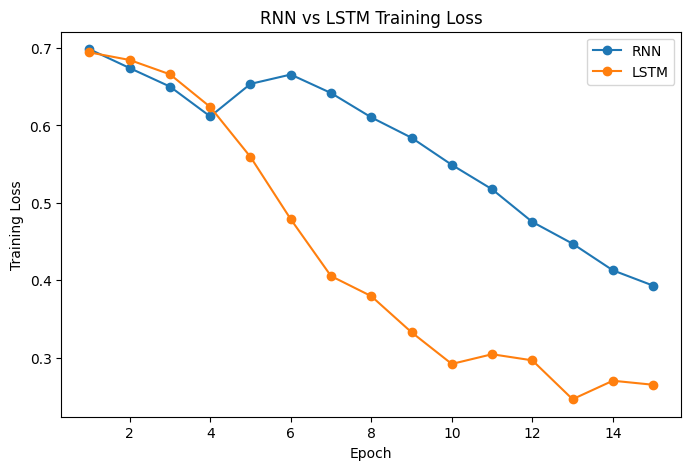

In [42]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, EPOCHS + 1),
    loss_history,
    marker="o",
    label="RNN"
)

plt.plot(
    range(1, LSTM_EPOCHS + 1),
    lstm_loss_history,
    marker="o",
    label="LSTM"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("RNN vs LSTM Training Loss")
plt.legend()

plt.show()

**Q1. Which model achieved higher test accuracy?**

ANS: LSTM achieved higher test accuracy than RNN. The LSTM achieved 57.83%, while the RNN achieved 52.00%.

**Q2. Did LSTM reach a lower training loss?**

ANS: Yes. The LSTM reached a lower final training loss of 0.2653 compared with 0.3932 for the RNN.

**Q3. Did RNN and LSTM agree on your custom reviews?**

ANS: 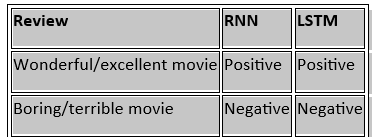


**Q4. What is LSTM doing differently?**

ANS: An RNN passes information through its hidden state, while an LSTM uses a cell state and gates to control what information should be remembered, updated, or forgotten. This helps the LSTM retain useful information for longer sequences and can reduce the vanishing-gradient problem.